100.0%
100.0%
100.0%
100.0%


Treino: 60000
Teste: 10000
Época 1/10 - Loss: 0.4089
Época 2/10 - Loss: 0.2068
Época 3/10 - Loss: 0.1502
Época 4/10 - Loss: 0.1189
Época 5/10 - Loss: 0.0990
Época 6/10 - Loss: 0.0835
Época 7/10 - Loss: 0.0715
Época 8/10 - Loss: 0.0626
Época 9/10 - Loss: 0.0547
Época 10/10 - Loss: 0.0476


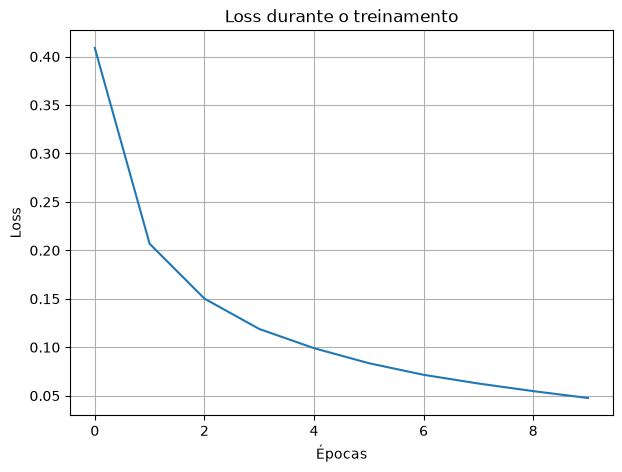



RESULTADO FINAL
Acurácia: 97.57%


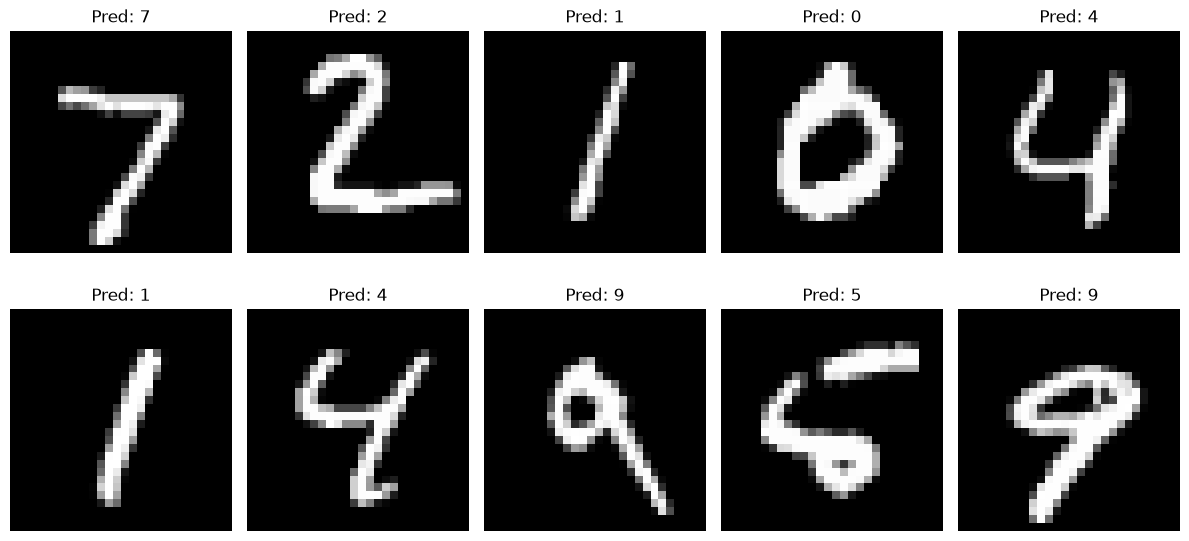

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ==========================================================
# 1. Carregando o MNIST
# ==========================================================

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Treino:", len(train_dataset))
print("Teste:", len(test_dataset))

# ==========================================================
# 2. Definindo a MLP
# ==========================================================

class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(28*28,64)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(64,10)

    def forward(self,x):

        x = x.view(-1,28*28)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x

model = MLP()

# ==========================================================
# 3. Função de perda e otimizador
# ==========================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ==========================================================
# 4. Treinamento
# ==========================================================

epochs = 10

losses = []

for epoch in range(epochs):

    running_loss = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    losses.append(epoch_loss)

    print(f"Época {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

# ==========================================================
# 5. Gráfico da Loss
# ==========================================================

plt.figure(figsize=(7,5))

plt.plot(losses)

plt.title("Loss durante o treinamento")

plt.xlabel("Épocas")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

# ==========================================================
# 6. Avaliação
# ==========================================================

model.eval()

predictions = []

targets = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        predictions.extend(predicted.numpy())

        targets.extend(labels.numpy())

accuracy = accuracy_score(targets,predictions)

print("\n")

print("="*50)

print("RESULTADO FINAL")

print("="*50)

print(f"Acurácia: {accuracy*100:.2f}%")

# ==========================================================
# 7. Exibindo algumas previsões
# ==========================================================

images, labels = next(iter(test_loader))

with torch.no_grad():

    outputs = model(images)

    _, predicted = torch.max(outputs,1)

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"Pred: {predicted[i].item()}")

    plt.axis("off")

plt.tight_layout()

plt.show()